In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")


In [20]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F9F9F9",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.size":        11,
})

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
MONSOON     = [6, 7, 8, 9, 10]   # June–October
PALETTE     = ["#3B8BD0","#E85D24","#2E9E6B","#9B59B6",
               "#E67E22","#1ABC9C","#E74C3C","#34495E"]


## Load all stations

In [21]:
DATA_DIR = "../data/processed"
stations = [f.replace("_clean.csv", "")
            for f in os.listdir(DATA_DIR) if f.endswith("_clean.csv")]
stations = sorted(stations)

all_data = {}
for station in stations:
    df = pd.read_csv(
        f"{DATA_DIR}/{station}_clean.csv",
        index_col="date", parse_dates=True
    )
    all_data[station] = df

print(f"✓ Loaded {len(all_data)} stations: {stations}")
print(f"  Date range : {list(all_data.values())[0].index.min().date()}"
      f" → {list(all_data.values())[0].index.max().date()}")
print(f"  Columns    : {list(list(all_data.values())[0].columns)}")

# Work with Dhaka as the primary focus station
df = all_data["dhaka"].copy()
print(f"\nDhaka shape: {df.shape}")
df.head()

✓ Loaded 8 stations: ['barisal', 'chittagong', 'dhaka', 'khulna', 'mymensingh', 'rajshahi', 'rangpur', 'sylhet']
  Date range : 2000-01-01 → 2023-12-31
  Columns    : ['rainfall_mm', 'temp_c', 'humidity_pct', 'wind_speed_ms', 'station']

Dhaka shape: (8766, 5)


,rainfall_mm,temp_c,humidity_pct,wind_speed_ms,station
date,,,,,
2000-01-01,0.0,17.56,68.01,2.58,dhaka
2000-01-02,0.0,17.46,66.91,2.16,dhaka
2000-01-03,0.0,17.20,62.91,2.37,dhaka
2000-01-04,0.0,16.99,62.36,3.07,dhaka
2000-01-05,0.0,16.97,63.31,2.63,dhaka


## Basic descriptive statistics

In [22]:
print("=" * 55)
print("  Dhaka — Descriptive Statistics")
print("=" * 55)

stats = df.describe().round(2)
display(stats)

print("\nKey observations:")
print(f"  Mean daily rainfall : {df['rainfall_mm'].mean():.2f} mm")
print(f"  Median              : {df['rainfall_mm'].median():.2f} mm")
print(f"  Std dev             : {df['rainfall_mm'].std():.2f} mm")
print(f"  Max single day      : {df['rainfall_mm'].max():.1f} mm"
      f"  on {df['rainfall_mm'].idxmax().date()}")
print(f"  Zero rain days      : {(df['rainfall_mm'] == 0).sum()}"
      f"  ({(df['rainfall_mm'] == 0).mean()*100:.1f}% of all days)")
print(f"  Heavy rain (>50mm)  : {(df['rainfall_mm'] > 50).sum()} days")
print(f"  Danger level (>120mm): {(df['rainfall_mm'] > 120).sum()} days")

  Dhaka — Descriptive Statistics


,rainfall_mm,temp_c,humidity_pct,wind_speed_ms
count,8766.00,8766.00,8766.00,8766.00
mean,6.02,25.50,75.04,2.88
std,11.23,4.37,15.41,1.28
min,0.00,10.71,26.40,0.60
25%,0.00,22.24,65.10,1.94
50%,1.24,27.43,79.40,2.58
75%,7.41,28.59,88.15,3.64
max,167.28,34.51,95.77,10.20



Key observations:
  Mean daily rainfall : 6.02 mm
  Median              : 1.24 mm
  Std dev             : 11.23 mm
  Max single day      : 167.3 mm  on 2004-09-13
  Zero rain days      : 3053  (34.8% of all days)
  Heavy rain (>50mm)  : 104 days
  Danger level (>120mm): 3 days


## Rainfall distribution (histogram + boxplot)

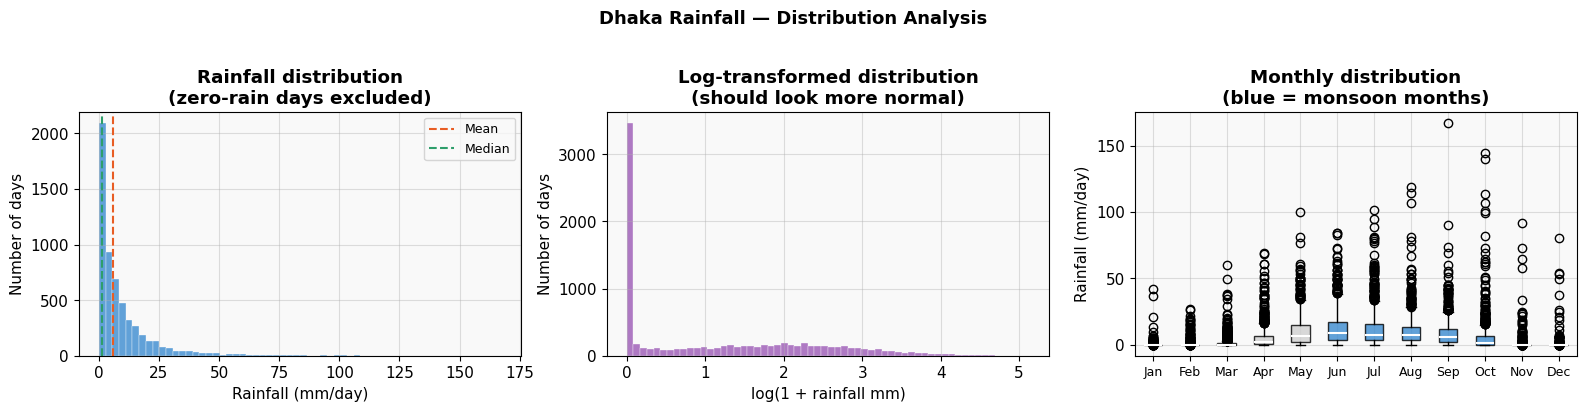

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left — histogram (log scale — rainfall is highly skewed)
ax = axes[0]
ax.hist(df["rainfall_mm"][df["rainfall_mm"] > 0],
        bins=60, color="#3B8BD0", alpha=0.8, edgecolor="white", lw=0.3)
ax.set_xlabel("Rainfall (mm/day)")
ax.set_ylabel("Number of days")
ax.set_title("Rainfall distribution\n(zero-rain days excluded)", fontweight="bold")
ax.axvline(df["rainfall_mm"].mean(),   color="#E85D24", lw=1.5, linestyle="--", label="Mean")
ax.axvline(df["rainfall_mm"].median(), color="#2E9E6B", lw=1.5, linestyle="--", label="Median")
ax.legend(fontsize=9)

# Middle — log-scale histogram (shows tail behaviour clearly)
ax = axes[1]
log_rain = np.log1p(df["rainfall_mm"])   # log1p handles zeros
ax.hist(log_rain, bins=60, color="#9B59B6", alpha=0.8, edgecolor="white", lw=0.3)
ax.set_xlabel("log(1 + rainfall mm)")
ax.set_ylabel("Number of days")
ax.set_title("Log-transformed distribution\n(should look more normal)", fontweight="bold")

# Right — monthly boxplot
ax = axes[2]
monthly_groups = [df[df.index.month == m]["rainfall_mm"].values
                  for m in range(1, 13)]
bp = ax.boxplot(monthly_groups, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=1.5))
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor("#3B8BD0" if (i+1) in MONSOON else "#D0D0D0")
    patch.set_alpha(0.8)
ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_ylabel("Rainfall (mm/day)")
ax.set_title("Monthly distribution\n(blue = monsoon months)", fontweight="bold")

plt.suptitle("Dhaka Rainfall — Distribution Analysis", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/raw/eda_01_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

## Year-over-year rainfall trends

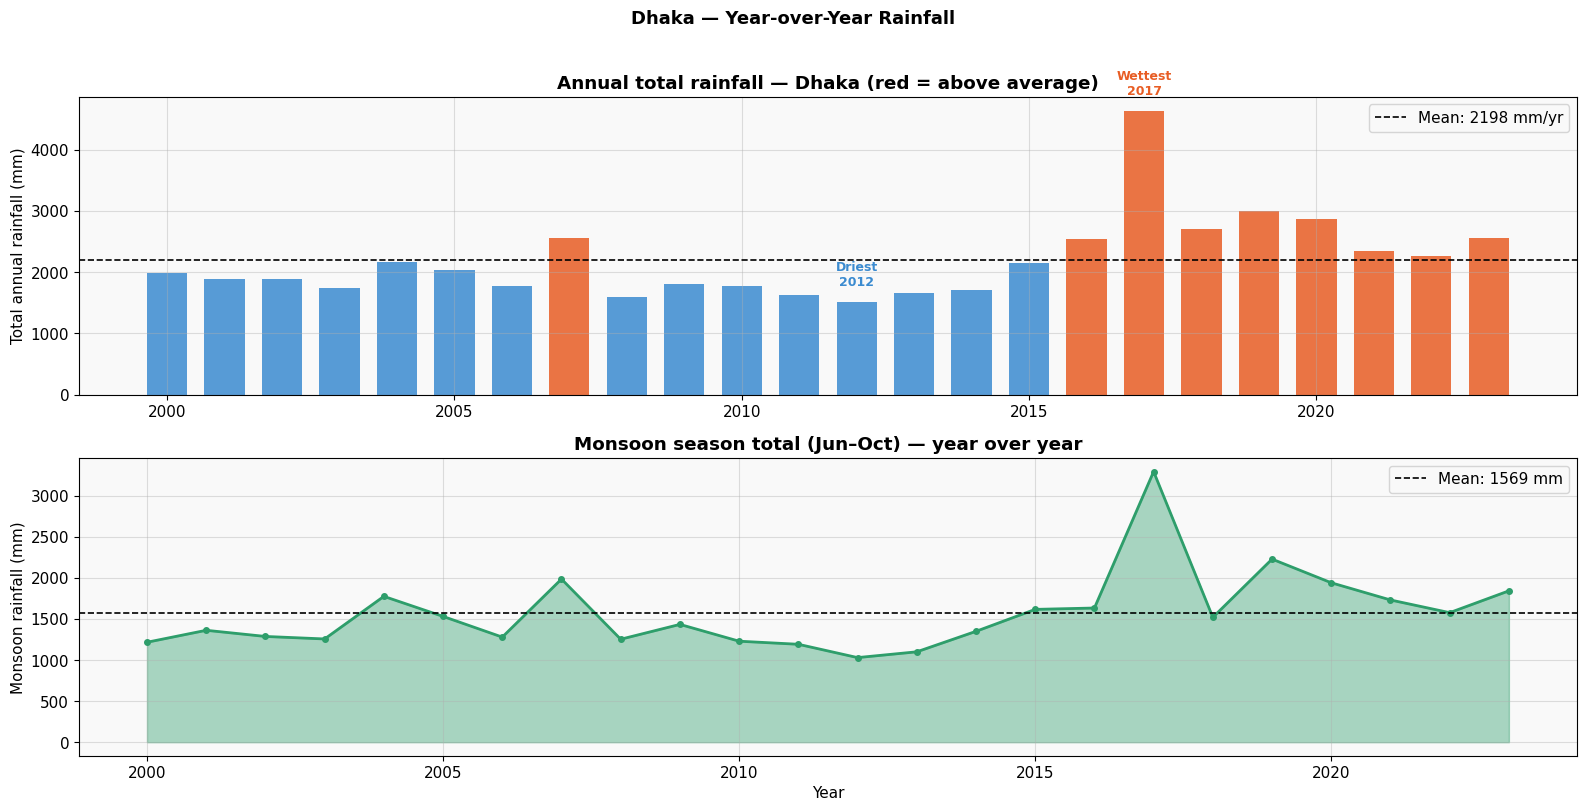

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Top — annual total rainfall
annual = df["rainfall_mm"].resample("YE").sum()
ax = axes[0]
colours = ["#E85D24" if v > annual.mean() else "#3B8BD0" for v in annual.values]
bars = ax.bar(annual.index.year, annual.values, color=colours, width=0.7, alpha=0.85)
ax.axhline(annual.mean(), color="black", lw=1.2, linestyle="--", label=f"Mean: {annual.mean():.0f} mm/yr")
ax.set_ylabel("Total annual rainfall (mm)")
ax.set_title("Annual total rainfall — Dhaka (red = above average)", fontweight="bold")
ax.legend()

# Annotate max and min years
max_yr = annual.idxmax().year; max_val = annual.max()
min_yr = annual.idxmin().year; min_val = annual.min()
ax.annotate(f"Wettest\n{max_yr}", xy=(max_yr, max_val),
            xytext=(0, 12), textcoords="offset points",
            ha="center", fontsize=9, color="#E85D24", fontweight="bold")
ax.annotate(f"Driest\n{min_yr}", xy=(min_yr, min_val),
            xytext=(0, 12), textcoords="offset points",
            ha="center", fontsize=9, color="#3B8BD0", fontweight="bold")

# Bottom — monsoon season rainfall per year (Jun–Oct only)
monsoon_annual = (
    df[df.index.month.isin(MONSOON)]["rainfall_mm"]
    .resample("YE").sum()
)
ax = axes[1]
ax.fill_between(monsoon_annual.index.year, monsoon_annual.values,
                alpha=0.4, color="#2E9E6B")
ax.plot(monsoon_annual.index.year, monsoon_annual.values,
        color="#2E9E6B", lw=2, marker="o", ms=4)
ax.axhline(monsoon_annual.mean(), color="black", lw=1.2,
           linestyle="--", label=f"Mean: {monsoon_annual.mean():.0f} mm")
ax.set_ylabel("Monsoon rainfall (mm)")
ax.set_title("Monsoon season total (Jun–Oct) — year over year", fontweight="bold")
ax.set_xlabel("Year")
ax.legend()

plt.suptitle("Dhaka — Year-over-Year Rainfall", fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/raw/eda_02_yearly.png", dpi=130, bbox_inches="tight")
plt.show()

 ## Seasonal decomposition

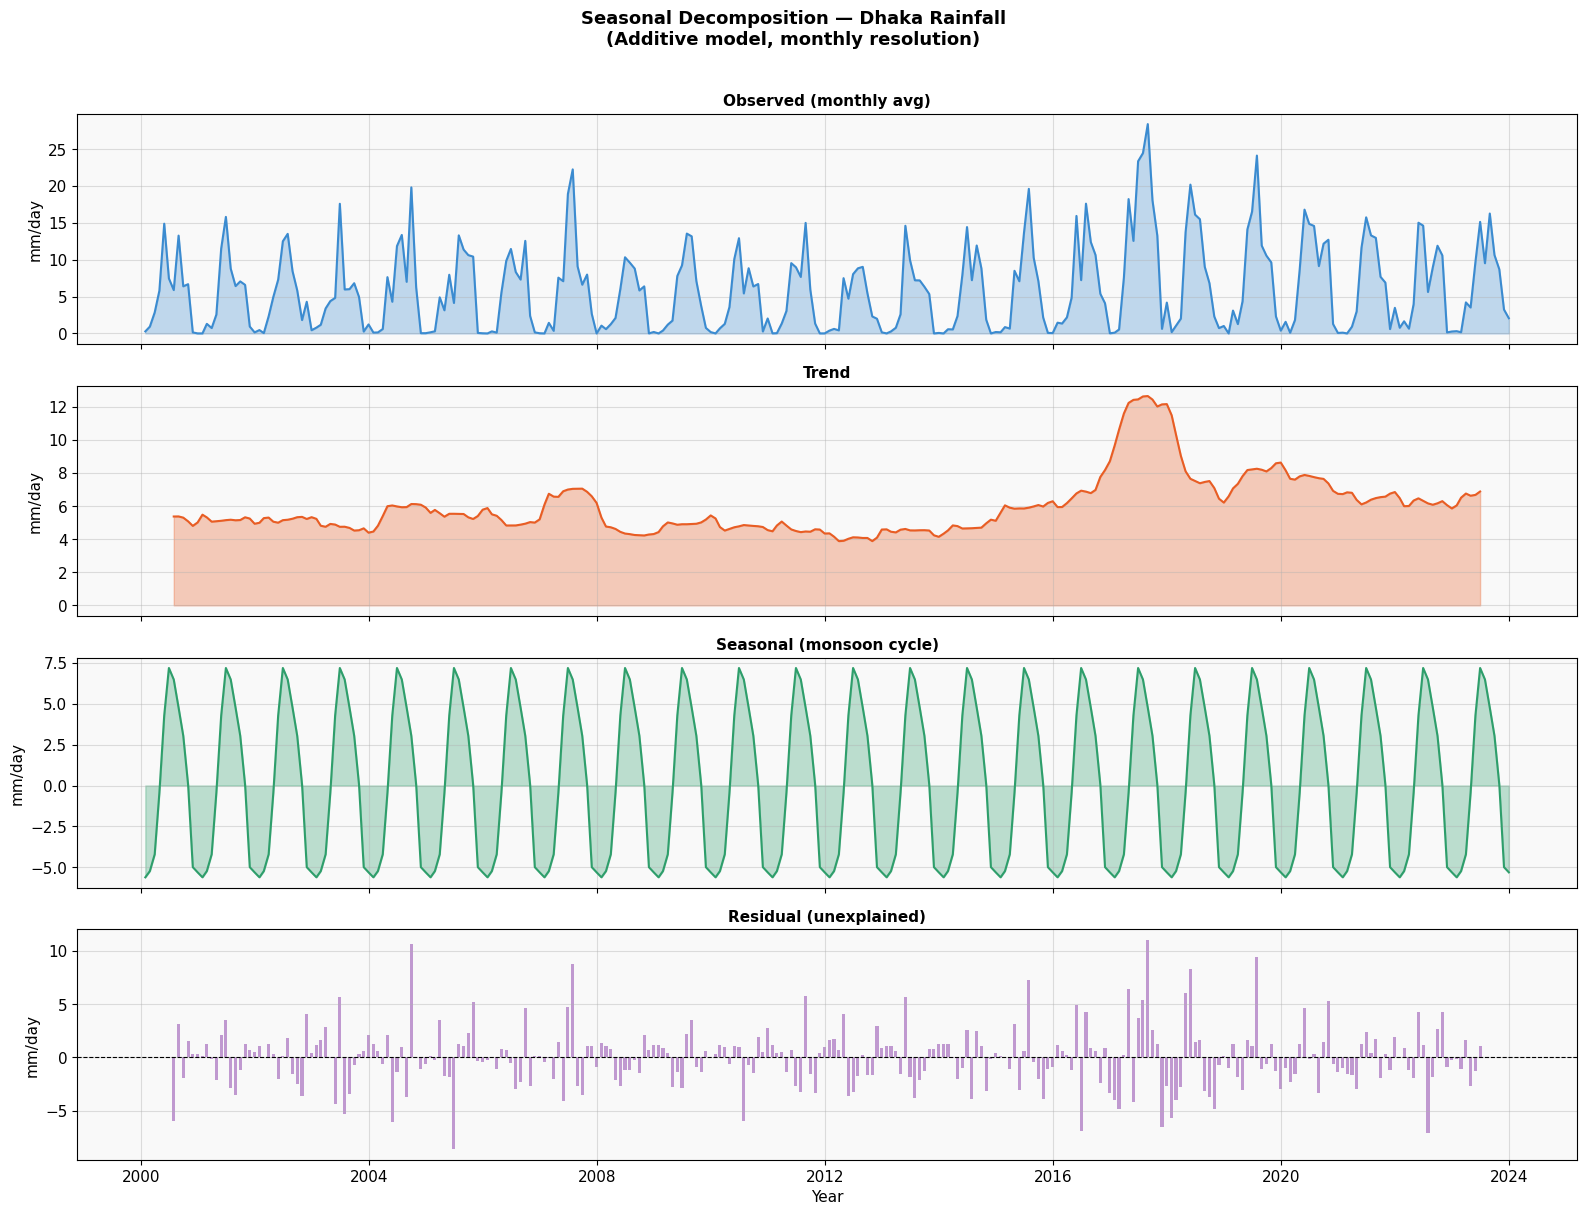

In [25]:
# Decompose into: trend + seasonal + residual
# Use additive model since rainfall has periods of near-zero (no multiplicative noise)
# period=365 captures the yearly monsoon cycle

# Resample to monthly average first (daily is too noisy for clean decomposition)
monthly_rain = df["rainfall_mm"].resample("ME").mean()

result = seasonal_decompose(monthly_rain, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
components = [
    (monthly_rain,       "Observed (monthly avg)",    "#3B8BD0"),
    (result.trend,       "Trend",                     "#E85D24"),
    (result.seasonal,    "Seasonal (monsoon cycle)",  "#2E9E6B"),
    (result.resid,       "Residual (unexplained)",     "#9B59B6"),
]

for ax, (data, title, colour) in zip(axes, components):
    if title == "Residual (unexplained)":
        ax.bar(data.index, data.values, color=colour, alpha=0.6, width=20)
        ax.axhline(0, color="black", lw=0.8, linestyle="--")
    else:
        ax.fill_between(data.index, data.values, alpha=0.3, color=colour)
        ax.plot(data.index, data.values, color=colour, lw=1.5)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel("mm/day")

axes[-1].set_xlabel("Year")
plt.suptitle("Seasonal Decomposition — Dhaka Rainfall\n"
             "(Additive model, monthly resolution)",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/raw/eda_03_decomposition.png", dpi=130, bbox_inches="tight")
plt.show()



## ADF Stationarity test

In [26]:
# Augmented Dickey-Fuller test
# H0 : series has a unit root (non-stationary)
# H1 : series is stationary
# If p-value < 0.05 → reject H0 → series IS stationary → good for ARIMA / XGBoost

def adf_test(series, name="Series"):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"\n  {'─'*40}")
    print(f"  ADF Test — {name}")
    print(f"  {'─'*40}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.6f}")
    print(f"  Lags used     : {result[2]}")
    print(f"  Observations  : {result[3]}")
    print(f"  Critical values:")
    for k, v in result[4].items():
        sig = "✓ stationary" if result[0] < v else ""
        print(f"    {k}: {v:.4f}  {sig}")
    conclusion = "✅ STATIONARY (p < 0.05)" if result[1] < 0.05 else "⚠ NON-STATIONARY (p ≥ 0.05)"
    print(f"\n  Conclusion: {conclusion}")
    return result[1]

print("Stationarity tests — Dhaka rainfall\n")
adf_test(df["rainfall_mm"],               "Raw daily rainfall")
adf_test(df["rainfall_mm"].diff().dropna(), "First difference")



Stationarity tests — Dhaka rainfall


  ────────────────────────────────────────
  ADF Test — Raw daily rainfall
  ────────────────────────────────────────
  ADF Statistic : -7.5027
  p-value       : 0.000000
  Lags used     : 37
  Observations  : 8728
  Critical values:
    1%: -3.4311  ✓ stationary
    5%: -2.8619  ✓ stationary
    10%: -2.5669  ✓ stationary

  Conclusion: ✅ STATIONARY (p < 0.05)

  ────────────────────────────────────────
  ADF Test — First difference
  ────────────────────────────────────────
  ADF Statistic : -25.0257
  p-value       : 0.000000
  Lags used     : 37
  Observations  : 8727
  Critical values:
    1%: -3.4311  ✓ stationary
    5%: -2.8619  ✓ stationary
    10%: -2.5669  ✓ stationary

  Conclusion: ✅ STATIONARY (p < 0.05)


0.0

## ACF and PACF plots

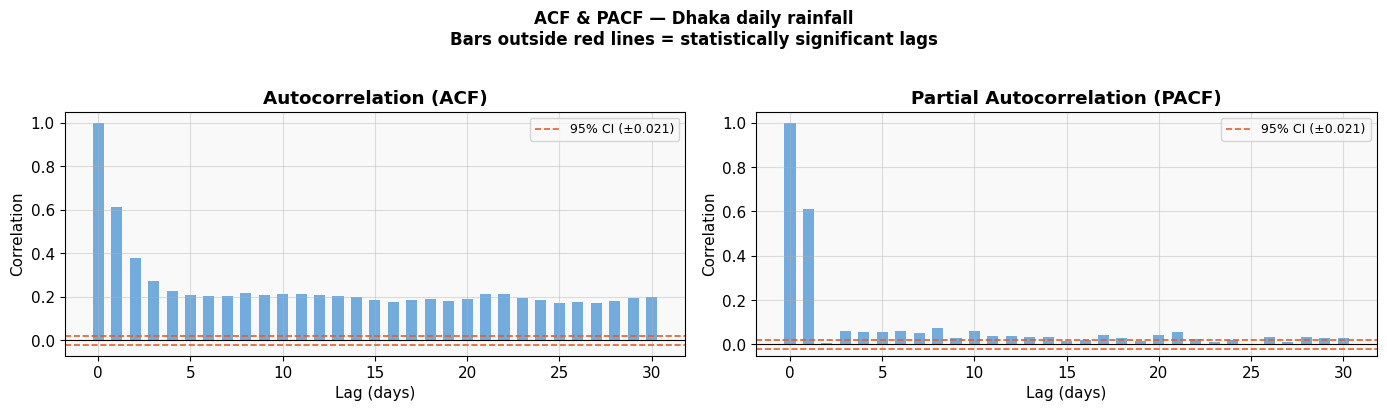


Significant PACF lags: [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 17, 18, 20, 21, 22, 26, 28, 29, 30]
→ Use these as lag values in feature engineering (notebook 03)


In [27]:
# ACF  — how correlated is rainfall today with rainfall N days ago?
# PACF — same, but removing indirect correlations in between
# Use these to decide lag values for feature engineering

n_lags = 30
rain_series = df["rainfall_mm"].dropna()

acf_vals  = acf(rain_series,  nlags=n_lags)
pacf_vals = pacf(rain_series, nlags=n_lags)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Confidence interval threshold
conf = 1.96 / np.sqrt(len(rain_series))

for ax, vals, title in zip(
    axes,
    [acf_vals, pacf_vals],
    ["Autocorrelation (ACF)", "Partial Autocorrelation (PACF)"]
):
    lags = range(len(vals))
    ax.bar(lags, vals, color="#3B8BD0", alpha=0.7, width=0.6)
    ax.axhline( conf, color="#E85D24", lw=1.2, linestyle="--", label=f"95% CI (±{conf:.3f})")
    ax.axhline(-conf, color="#E85D24", lw=1.2, linestyle="--")
    ax.axhline(0,     color="black",   lw=0.8)
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Correlation")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("ACF & PACF — Dhaka daily rainfall\n"
             "Bars outside red lines = statistically significant lags",
             fontweight="bold", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../data/raw/eda_04_acf_pacf.png", dpi=130, bbox_inches="tight")
plt.show()

# Find significant lags
sig_lags = [i for i, v in enumerate(pacf_vals) if abs(v) > conf and i > 0]
print(f"\nSignificant PACF lags: {sig_lags}")
print("→ Use these as lag values in feature engineering (notebook 03)")

## Rolling statistics (spot non-stationarity)

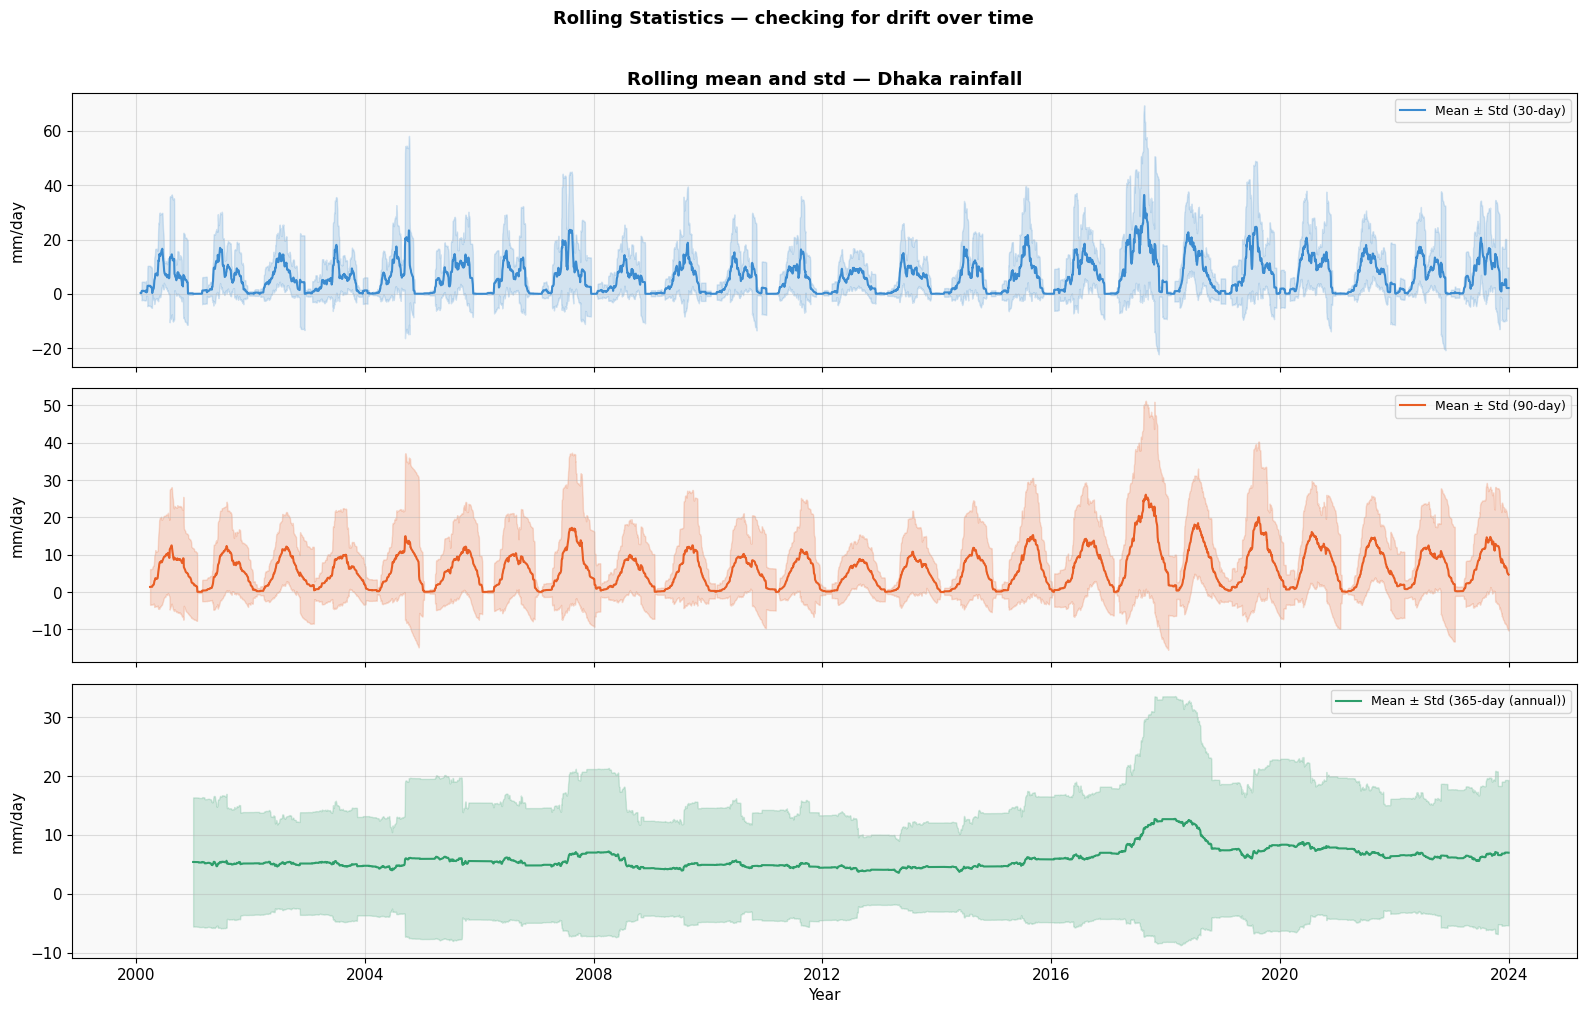

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

windows = [30, 90, 365]
colours  = ["#3B8BD0", "#E85D24", "#2E9E6B"]
labels   = ["30-day", "90-day", "365-day (annual)"]

rain = df["rainfall_mm"]

for ax, w, c, lbl in zip(axes, windows, colours, labels):
    roll_mean = rain.rolling(w).mean()
    roll_std  = rain.rolling(w).std()

    ax.fill_between(rain.index,
                    roll_mean - roll_std,
                    roll_mean + roll_std,
                    alpha=0.2, color=c)
    ax.plot(rain.index, roll_mean, color=c, lw=1.5, label=f"Mean ± Std ({lbl})")
    ax.set_ylabel("mm/day")
    ax.legend(loc="upper right", fontsize=9)

axes[0].set_title("Rolling mean and std — Dhaka rainfall", fontweight="bold")
axes[-1].set_xlabel("Year")

plt.suptitle("Rolling Statistics — checking for drift over time",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/raw/eda_05_rolling.png", dpi=130, bbox_inches="tight")
plt.show()



## Extreme rainfall events (flood risk context)

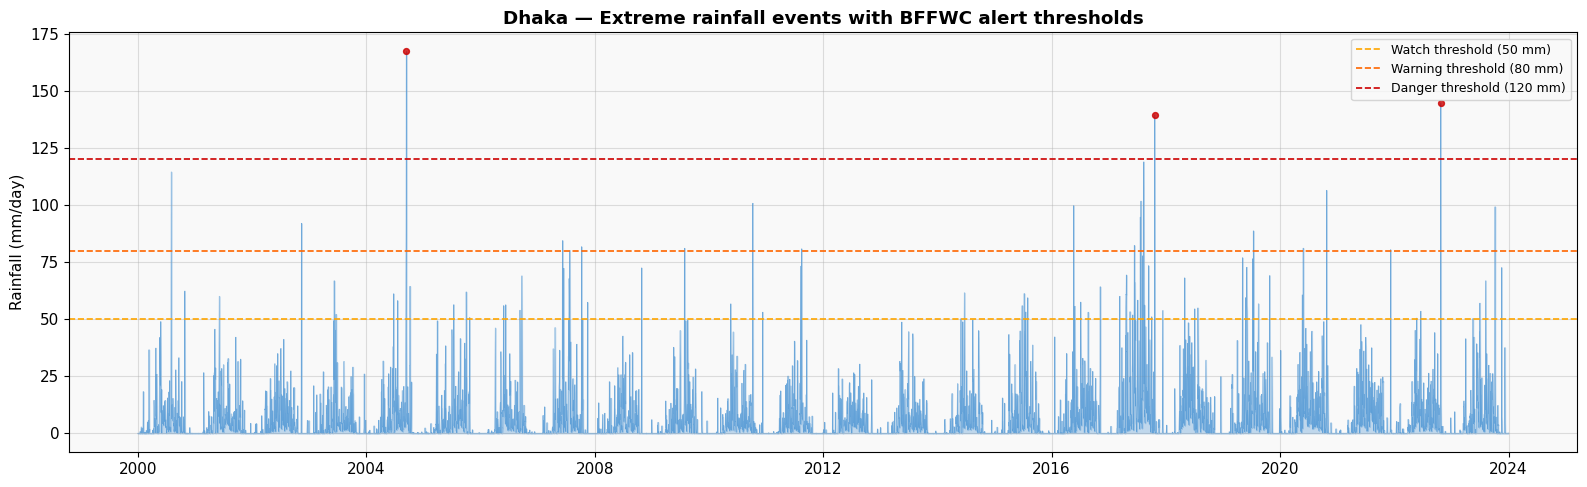

Extreme event summary — Dhaka:
  Watch    (>50mm):  104 days (1.19%)  avg 4.3 days/year
  Warning  (>80mm):   25 days (0.29%)  avg 1.0 days/year
  Danger   (>120mm):    3 days (0.03%)  avg 0.1 days/year


In [30]:
# Identify historically dangerous days — these are your ground truth for flood risk

THRESHOLDS = {"Watch": 50, "Warning": 80, "Danger": 120}

fig, ax = plt.subplots(figsize=(16, 5))

rain = df["rainfall_mm"]
ax.fill_between(rain.index, rain, alpha=0.3, color="#3B8BD0")
ax.plot(rain.index, rain, lw=0.4, color="#3B8BD0", alpha=0.6)

colours_thresh = {"Watch": "#FFA500", "Warning": "#FF6600", "Danger": "#CC0000"}
for label, val in THRESHOLDS.items():
    ax.axhline(val, color=colours_thresh[label], lw=1.2,
               linestyle="--", label=f"{label} threshold ({val} mm)")

    # Highlight days above danger
    if label == "Danger":
        danger_days = rain[rain > val]
        ax.scatter(danger_days.index, danger_days.values,
                   color="#CC0000", s=18, zorder=5, alpha=0.8)

ax.set_ylabel("Rainfall (mm/day)")
ax.set_title("Dhaka — Extreme rainfall events with BFFWC alert thresholds",
             fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../data/raw/eda_06_extremes.png", dpi=130, bbox_inches="tight")
plt.show()

print("Extreme event summary — Dhaka:")
for label, val in THRESHOLDS.items():
    count = (rain > val).sum()
    pct   = (rain > val).mean() * 100
    years = (rain > val).resample("YE").sum()
    print(f"  {label:8} (>{val}mm): {count:4d} days "
          f"({pct:.2f}%)  avg {years.mean():.1f} days/year")

##  Cross-station correlation heatmap

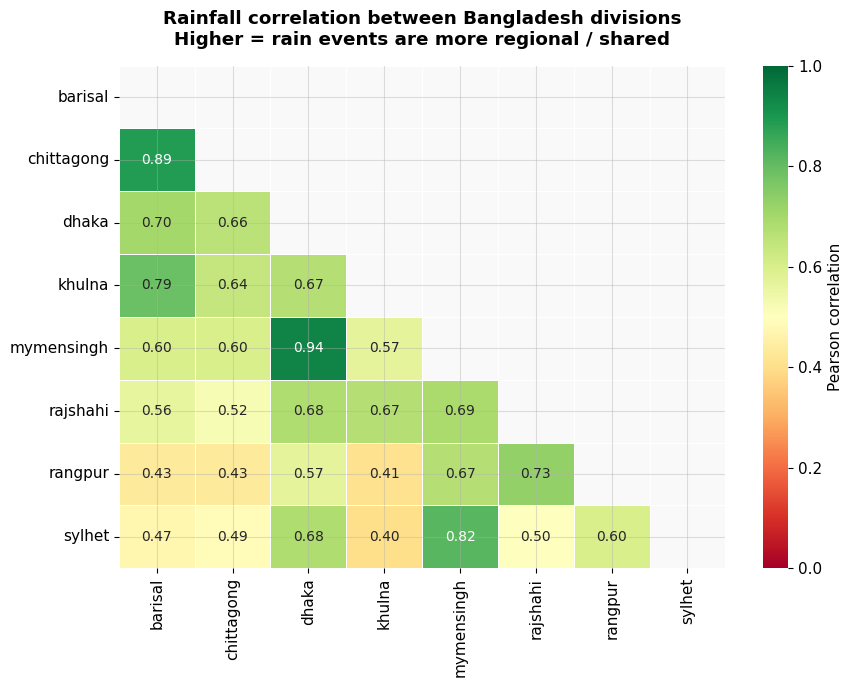

High correlation (>0.7) → spatial feature could help the model
Low correlation (<0.4) → divisions have very different rainfall patterns


In [31]:
# Are neighbouring divisions correlated?
# High correlation → flood events are regional, not just local

wide = pd.concat(
    {s: d["rainfall_mm"] for s, d in all_data.items()},
    axis=1
)
corr = wide.corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True          # hide upper triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 10},
    cbar_kws={"label": "Pearson correlation"}
)
ax.set_title("Rainfall correlation between Bangladesh divisions\n"
             "Higher = rain events are more regional / shared",
             fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../data/raw/eda_07_correlation.png", dpi=130, bbox_inches="tight")
plt.show()

print("High correlation (>0.7) → spatial feature could help the model")
print("Low correlation (<0.4) → divisions have very different rainfall patterns")

## Temperature vs rainfall relationship

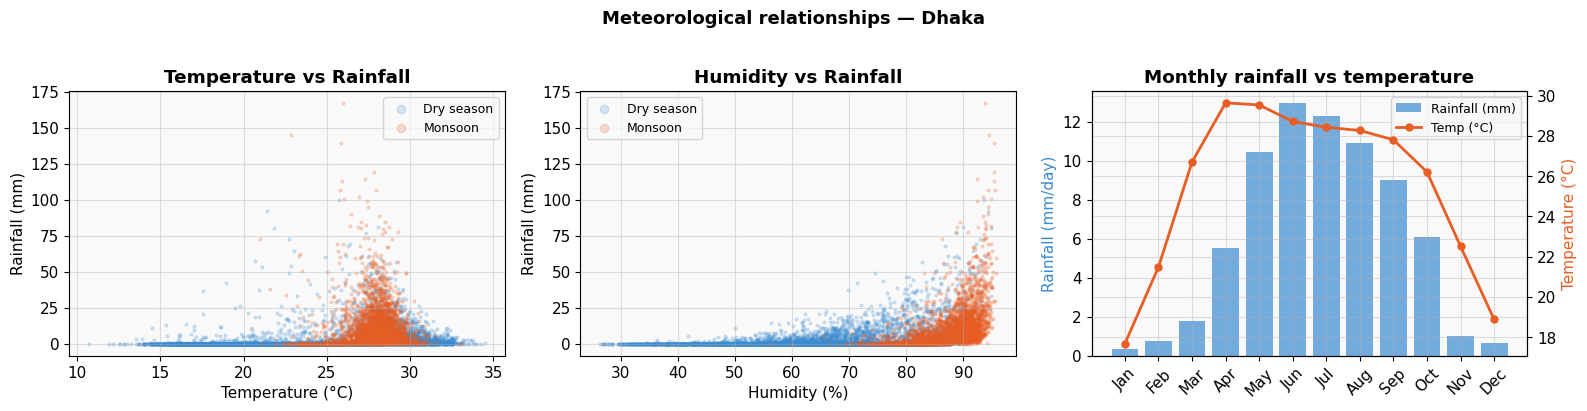


Correlation — rainfall vs temperature : 0.274
Correlation — rainfall vs humidity   : 0.419

→ Features with |corr| > 0.3 are worth including in XGBoost


In [32]:
# Warm, humid air drives convection → rainfall
# Understanding this relationship informs which meteorological features to use

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scatter: temp vs rainfall
ax = axes[0]
monsoon_mask = df.index.month.isin(MONSOON)
ax.scatter(df.loc[~monsoon_mask, "temp_c"],
           df.loc[~monsoon_mask, "rainfall_mm"],
           alpha=0.2, s=4, color="#3B8BD0", label="Dry season")
ax.scatter(df.loc[monsoon_mask, "temp_c"],
           df.loc[monsoon_mask, "rainfall_mm"],
           alpha=0.2, s=4, color="#E85D24", label="Monsoon")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Rainfall (mm)")
ax.set_title("Temperature vs Rainfall", fontweight="bold")
ax.legend(fontsize=9, markerscale=3)

# Scatter: humidity vs rainfall
ax = axes[1]
ax.scatter(df.loc[~monsoon_mask, "humidity_pct"],
           df.loc[~monsoon_mask, "rainfall_mm"],
           alpha=0.2, s=4, color="#3B8BD0", label="Dry season")
ax.scatter(df.loc[monsoon_mask, "humidity_pct"],
           df.loc[monsoon_mask, "rainfall_mm"],
           alpha=0.2, s=4, color="#E85D24", label="Monsoon")
ax.set_xlabel("Humidity (%)")
ax.set_ylabel("Rainfall (mm)")
ax.set_title("Humidity vs Rainfall", fontweight="bold")
ax.legend(fontsize=9, markerscale=3)

# Monthly average temp and rainfall overlaid
ax = axes[2]
monthly_rain = df.groupby(df.index.month)["rainfall_mm"].mean()
monthly_temp = df.groupby(df.index.month)["temp_c"].mean()
ax2 = ax.twinx()
ax.bar(MONTH_NAMES, monthly_rain.values,
       color="#3B8BD0", alpha=0.7, label="Rainfall (mm)")
ax2.plot(MONTH_NAMES, monthly_temp.values,
         color="#E85D24", lw=2, marker="o", ms=5, label="Temp (°C)")
ax.set_ylabel("Rainfall (mm/day)", color="#3B8BD0")
ax2.set_ylabel("Temperature (°C)", color="#E85D24")
ax.set_title("Monthly rainfall vs temperature", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.suptitle("Meteorological relationships — Dhaka",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/raw/eda_08_meteo_relationships.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"\nCorrelation — rainfall vs temperature : "
      f"{df['rainfall_mm'].corr(df['temp_c']):.3f}")
print(f"Correlation — rainfall vs humidity   : "
      f"{df['rainfall_mm'].corr(df['humidity_pct']):.3f}")
print("\n→ Features with |corr| > 0.3 are worth including in XGBoost")

##   Key findings summary

In [33]:
print("=" * 55)
print("  EDA Summary — Key Findings")
print("=" * 55)

rain = df["rainfall_mm"]

print(f"""
1. DISTRIBUTION
   Rainfall is heavily right-skewed (many zero days,
   rare extreme events). Median {rain.median():.1f} mm << Mean {rain.mean():.1f} mm.
   Log-transform or Tweedie loss may help XGBoost.

2. SEASONALITY
   Strong yearly monsoon cycle (Jun–Oct).
   Seasonal decomposition confirms this.
   Prophet will capture this automatically.
   XGBoost needs explicit sin/cos calendar features.

3. STATIONARITY
   Daily series is stationary (ADF p < 0.05).
   No differencing needed before modelling.

4. SIGNIFICANT LAGS (from PACF)
   Use these in feature engineering notebook:
   lag-1, lag-3, lag-7, lag-14 at minimum.

5. EXTREME EVENTS
   Danger-level days (>120mm): {(rain > 120).sum()} total
   ~{(rain > 120).resample('YE').sum().mean():.1f} per year on average.
   These are the days the flood alert system must catch.

6. STATION CORRELATIONS
   Check correlation matrix above for which divisions
   are most similar — useful for multi-station modelling.

7. USEFUL FEATURES FOR XGBOOST
   - rainfall lags (1, 3, 7, 14 days)
   - rolling mean and std (7, 30 days)
   - humidity (correlated with rainfall)
   - sin/cos day-of-year (monsoon encoding)
   - is_monsoon binary flag
""")



  EDA Summary — Key Findings

1. DISTRIBUTION
   Rainfall is heavily right-skewed (many zero days,
   rare extreme events). Median 1.2 mm << Mean 6.0 mm.
   Log-transform or Tweedie loss may help XGBoost.

2. SEASONALITY
   Strong yearly monsoon cycle (Jun–Oct).
   Seasonal decomposition confirms this.
   Prophet will capture this automatically.
   XGBoost needs explicit sin/cos calendar features.

3. STATIONARITY
   Daily series is stationary (ADF p < 0.05).
   No differencing needed before modelling.

4. SIGNIFICANT LAGS (from PACF)
   Use these in feature engineering notebook:
   lag-1, lag-3, lag-7, lag-14 at minimum.

5. EXTREME EVENTS
   Danger-level days (>120mm): 3 total
   ~0.1 per year on average.
   These are the days the flood alert system must catch.

6. STATION CORRELATIONS
   Check correlation matrix above for which divisions
   are most similar — useful for multi-station modelling.

7. USEFUL FEATURES FOR XGBOOST
   - rainfall lags (1, 3, 7, 14 days)
   - rolling mean a